# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from math import ceil, floor
from scipy.stats import ttest_ind 
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest


In [2]:
sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

In [3]:
sessions_history.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.



In [4]:
sessions_count = sessions_history.groupby('user_id', as_index=False).agg({'session_id':'count'}).rename(columns={'session_id':'sessions_count'})

In [5]:
max_count_uid = sessions_count.loc[sessions_count['sessions_count'].idxmax(), 'user_id']

In [6]:
sessions_history[sessions_history['user_id'] == max_count_uid]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования.

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [7]:
data = sessions_history.groupby('session_date', as_index=False).agg({'user_id':'count', 'registration_flag':'sum'}).rename(columns={'user_id':'total_count', 'registration_flag':'reg_count'})

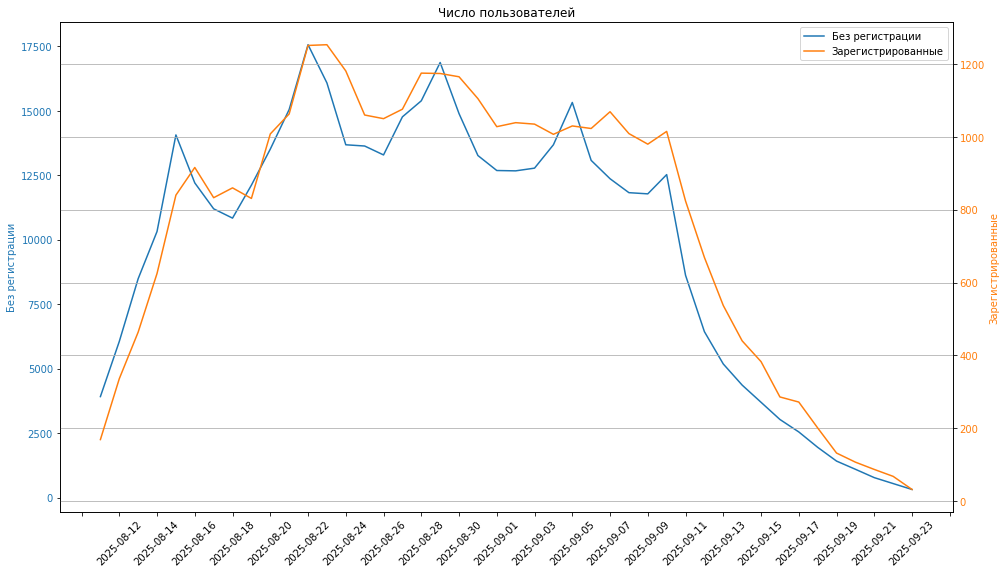

In [8]:
x = data.iloc[:, 0]
y1 = data.iloc[:, 1]
y2 = data.iloc[:, 2]

fig, ax1 = plt.subplots(figsize=(16, 9))

ax1.plot(x, y1, label='Без регистрации', color='C0')
ax1.set_ylabel('Без регистрации', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

ax2 = ax1.twinx()
ax2.plot(x, y2, label = 'Зарегистрированные', color='C1')
ax2.set_ylabel('Зарегистрированные', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

plt.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Число пользователей')
plt.xlabel('Дата')
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))

for label in ax1.get_xticklabels():
    label.set_rotation(45)

plt.show()


**Вывод:**   
Динамика количества пользователей между группами почти одинаковая. Следовательно, всё хорошо.

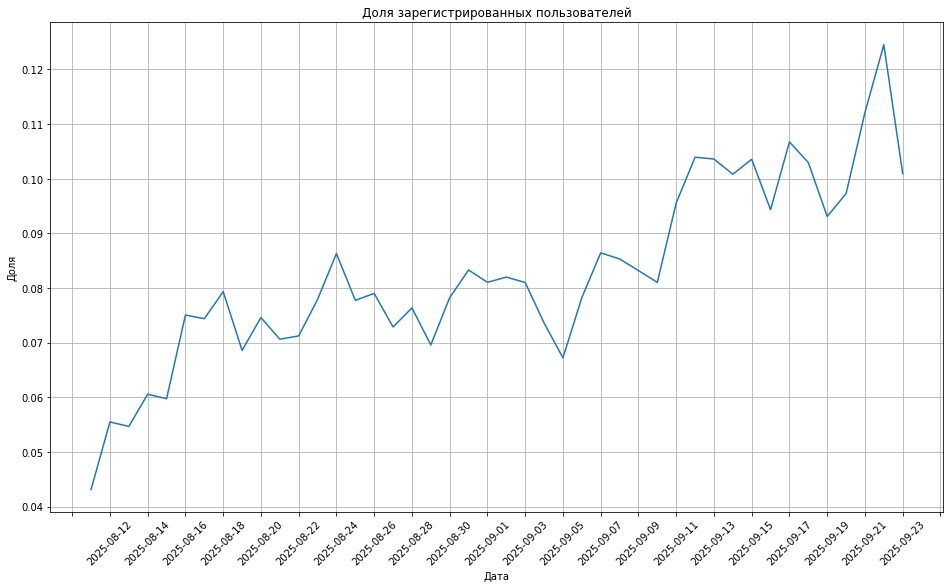

In [9]:
y3 = y2/y1

plt.figure(figsize=(16,9))
plt.plot(x, y3)
plt.title('Доля зарегистрированных пользователей')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)
plt.grid(True)

**Вывод:**  
На графике видна положителная динамика роста доли зарегистрированных пользователей. Небольшой спад наблюдался 09.05 и пик 09.22

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

- Найдите количество сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [10]:
page_count_df = sessions_history.groupby('page_counter', as_index=False)['session_id'].count()
page_count_df

,page_counter,session_id
0,1,29160
1,2,105536
2,3,166690
3,4,105569
4,5,26288
5,6,2589
6,7,92


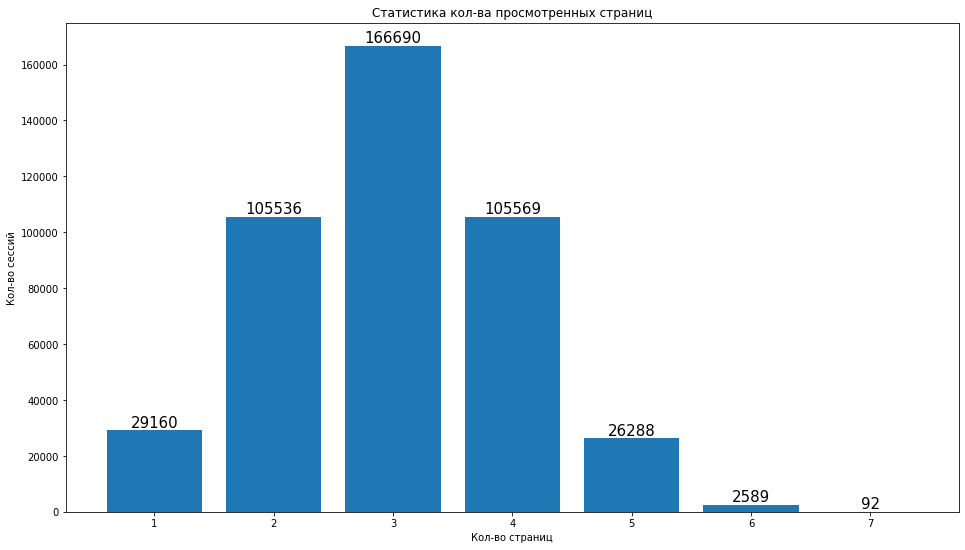

In [11]:
plt.figure(figsize=(16,9))
plt.bar(page_count_df.iloc[:,0], page_count_df.iloc[:,1])
plt.title('Статистика кол-ва просмотренных страниц')
plt.xlabel('Кол-во страниц')
plt.ylabel('Кол-во сессий')

for x, y in zip(page_count_df.iloc[:,0], page_count_df.iloc[:,1]):
    plt.text(
        x,
        y,
        str(y),
        ha='center',
        va='bottom',
        fontsize=15
    )

plt.show()

**Вывод:**  
2-4 страниц просмтривают большинство пользователей в течении сессии, чаще всего пользователи просматривают 3 страницы за сессию

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения.

In [12]:
sessions_history['good_session'] = (sessions_history['page_counter'] > 3).astype('int')
sessions_history.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0


In [13]:
good_sessions_df = sessions_history.groupby('session_date', as_index=False).agg({'good_session':'sum', 'session_id':'count'}).rename(columns={'good_session':'good_count', 'session_id':'total_count'})
good_sessions_df['percentage'] = good_sessions_df['good_count']/good_sessions_df['total_count']
good_sessions_df.head(5)

,session_date,good_count,total_count,percentage
0,2025-08-11,1226,3919,0.312835
1,2025-08-12,1829,6056,0.302015
2,2025-08-13,2604,8489,0.306750
3,2025-08-14,3262,10321,0.316055
4,2025-08-15,4289,14065,0.304941


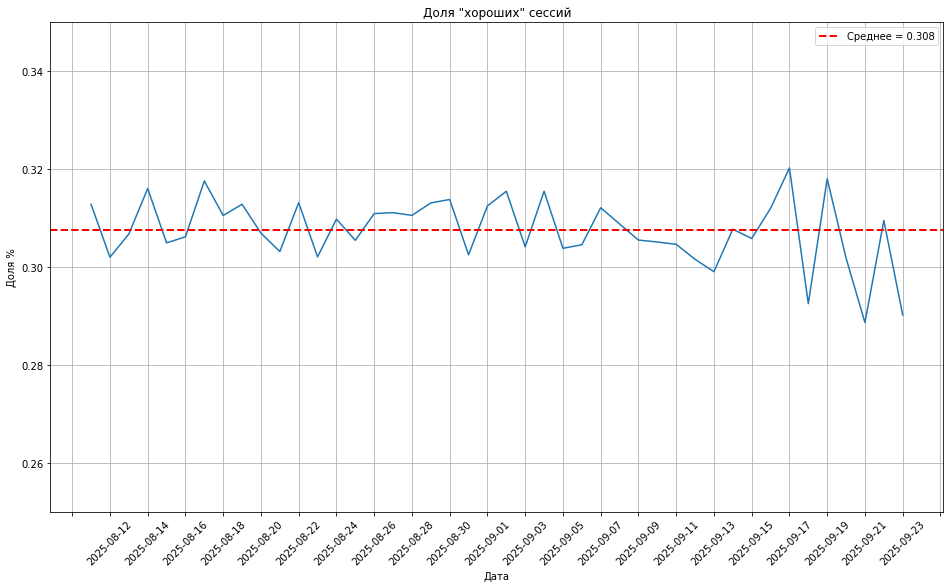

In [14]:
x = good_sessions_df.iloc[:, 0]
y = good_sessions_df.iloc[:, 3]

plt.figure(figsize=(16,9))
plt.plot(x,y)
plt.title('Доля "хороших" сессий')
plt.xlabel('Дата')
plt.ylabel('Доля %')
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)
plt.grid(True)
plt.ylim(0.25, 0.35)

mean_value = y.mean()
plt.axhline(mean_value, color='red', linestyle='--', linewidth=2, label=f'Среднее = {mean_value:.3f}')

plt.legend()
plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Сформулировать нулевую и альтернативную гипотезы

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1 Формулировка нулевой и альтернативной гипотез

Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

О какой метрике идёт речь? Как она будет учтена в формулировке гипотез?

Думаю, речь идет о количестве просмотренных страниц за сессию  
Формулировка гипотез: Изменения алгоритмов положительно влияют на ср. число просмотренных страниц

Сформулируйте нулевую и альтернативную гипотезы:

Изменения алгоритмов:  
**H0:** не влияют на ср. число просмотренных страниц

**H1:** *увеличивает* ср. число просмотенных страниц




#### 2.2. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [15]:

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.3. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [16]:

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = floor(sessions_history.groupby('session_date')['session_id'].count().mean())

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [17]:
sessions_project_test_part_df = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')
sessions_project_test_part_df.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [18]:
A_group = sessions_project_test_part_df[sessions_project_test_part_df['test_group'] == 'A']
B_group = sessions_project_test_part_df[sessions_project_test_part_df['test_group'] == 'B']

print(A_group['user_id'].nunique(), B_group['user_id'].nunique())
lst = [A_group['user_id'].nunique(), B_group['user_id'].nunique()]

1477 1466


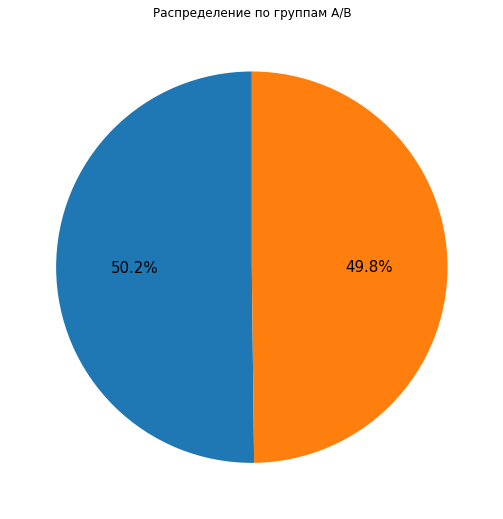

Процентная разница выборок: 0.74%


In [19]:
P = round((abs(1477-1466)/1477) * 100,2)

plt.figure(figsize=(16,9))
plt.pie(
    lst,
    autopct='%1.1f%%',
    textprops={'fontsize': 15},
    startangle=90
)
plt.title("Распределение по группам A/B")
plt.show()

print(f'Процентная разница выборок: {P}%')

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [20]:
set(A_group['user_id']) & set(B_group['user_id'])

set()

**Выборки независимы**

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


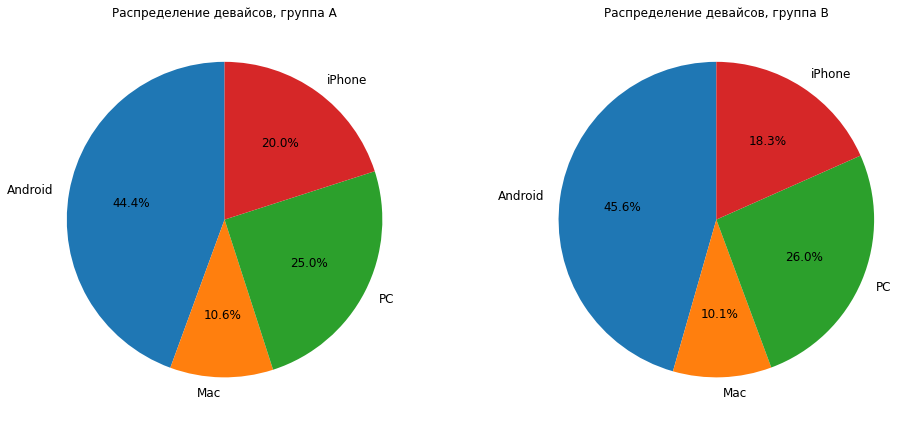

In [21]:
A_device_dist = A_group.groupby('device')['user_id'].nunique()
B_device_dist = B_group.groupby('device')['user_id'].nunique()

A_device_percent = A_device_dist / A_device_dist.sum() * 100
B_device_percent = B_device_dist / B_device_dist.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14,6))

axes[0].pie(
    A_device_percent,
    autopct='%1.1f%%',
    labels=A_device_percent.index,
    textprops={'fontsize': 12},
    startangle=90
)
axes[0].set_title("Распределение девайсов, группа A")

axes[1].pie(
    B_device_percent,
    autopct='%1.1f%%',
    labels=B_device_percent.index,
    textprops={'fontsize': 12},
    startangle=90
)
axes[1].set_title("Распределение девайсов, группа B")

plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.


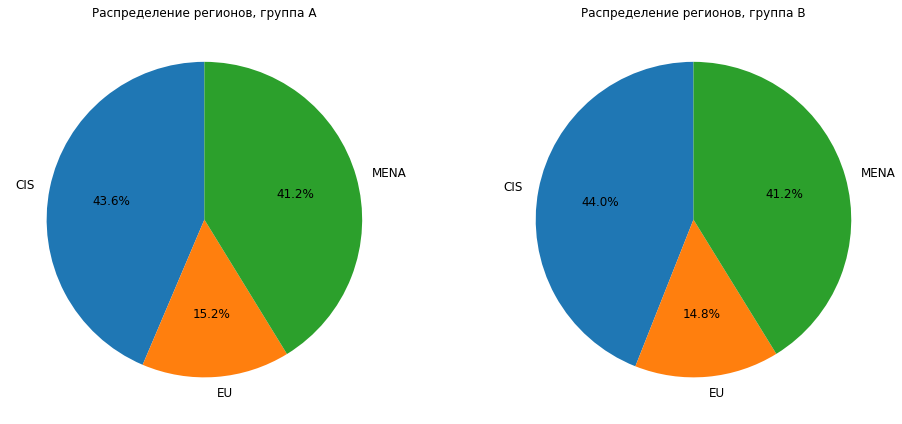

In [22]:
A_region_dist = A_group.groupby('region')['user_id'].nunique()
B_region_dist = B_group.groupby('region')['user_id'].nunique()

A_region_percent = A_region_dist / A_region_dist.sum() * 100
B_region_percent = B_region_dist / B_region_dist.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14,6))

axes[0].pie(
    A_region_percent,
    autopct='%1.1f%%',
    labels=A_region_percent.index,
    textprops={'fontsize': 12},
    startangle=90
)
axes[0].set_title("Распределение регионов, группа A")

axes[1].pie(
    B_region_percent,
    autopct='%1.1f%%',
    labels=B_region_percent.index,
    textprops={'fontsize': 12},
    startangle=90
)
axes[1].set_title("Распределение регионов, группа B")

plt.tight_layout()
plt.show()

*Выбран тот же вид диаграмы, так как он наиболее наглядно демострирует распределение*

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

На основе проведнного анализа A/B теста можно сделать следующие выводы:  
* Данные распределены равномерно  
* Выборки независимы  
* Сохраняется равномерное распеделение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.  

Т.О. A/B тест проходит корректно

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [23]:
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')
sessions_test['good_session'] = (sessions_test['page_counter'] > 3).astype('int')
sessions_test.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2. Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, необходимо убедиться, что тест проведён корректно и вы будете сравнивать две сопоставимые группы.

- Рассчитайте количество уникальных сессий для каждого дня и обеих тестовых групп, используя группировку.

- Проверьте, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми. Используйте статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

- В качестве ответа выведите на экран полученное значение p-value и интерпретируйте его.

In [24]:
daily_sessions_count = sessions_test.groupby('session_date', as_index=False)['session_id'].nunique()
daily_sessions_count.head(5)

,session_date,session_id
0,2025-10-14,3130
1,2025-10-15,4518
2,2025-10-16,6521
3,2025-10-17,8143
4,2025-10-18,10072


In [25]:
A_group = sessions_test[sessions_test['test_group'] == 'A']
B_group = sessions_test[sessions_test['test_group'] == 'B']
print(A_group.shape[0])
print(B_group.shape[0])

49551
50454


Напомним проверяемые гипотезы:
* H₀ — количество уникальных дневных сессий не различается между тестовой и контрольной группами.
* H₁ — количество уникальных дневных сессий различается между тестовой и контрольной группами (ожидается прирост числа сессий в тестовой выборке).

In [26]:
A_group = sessions_test[sessions_test['test_group'] == 'A']
B_group = sessions_test[sessions_test['test_group'] == 'B']

A_group_sessions = A_group.groupby('session_date')['session_id'].nunique()
B_group_sessions = B_group.groupby('session_date')['session_id'].nunique()

alpha = 0.05
result = ttest_ind(A_group_sessions, B_group_sessions, alternative='two-sided')

print(f'p_value = {result.pvalue}')
if result.pvalue > alpha:
    print('Выборки статистически не различаются')
else:
    print('Выборки имеют статистически значимое различие')

p_value = 0.938219304859116
Выборки статистически не различаются


#### 4.3. Сравнение доли успешных сессий

Когда вы убедились, что количество сессий в обеих выборках не различалось, можно переходить к анализу ключевой метрики — доли успешных сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [27]:
A_good = A_group['good_session'].sum()
A_total = A_group['good_session'].count()
B_good = B_group['good_session'].sum()
B_total = B_group['good_session'].count()

A_percentage = A_good / A_total
B_percentage = B_good / B_total

difference = A_percentage - B_percentage

print(f"Доля успешных сессий в группе A: {A_percentage:.4f} ({A_percentage:.2%})")
print(f"Доля успешных сессий в группе B: {B_percentage:.4f} ({B_percentage:.2%})")
print(f"Разница долей A - B: {difference:.4f} ({difference:.2%})")


Доля успешных сессий в группе A: 0.3077 (30.77%)
Доля успешных сессий в группе B: 0.3183 (31.83%)
Разница долей A - B: -0.0106 (-1.06%)


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [28]:
count = [B_good, A_good]       
nobs = [B_total, A_total]     

stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f"Z-статистика: {stat:.4f}")
print(f"p_value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print("Разница статистически значима => отвергаем H0.")
else:
    print("Разница НЕ статистически значима => нет оснований отвергать H0")


Z-статистика: 3.6027
p_value: 0.000157
Разница статистически значима => отвергаем H0.


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

### Выводы по результатам A/B-теста нового алгоритма рекомендаций

В рамках эксперимента пользователи были случайным образом разделены на две группы:

* Группа A — контрольная, использовала текущий алгоритм рекомендаций
* Группа B — тестовая, использовала новый алгоритм рекомендаций

Эксперимент длился 20 дней.
В тесте участвовало 49551 пользователей в группе A и 50454 пользователей в группе B.  

В группе A доля успешных сессий составила **30.77%**

В группе B доля успешных сессий составила **31.83%**

Относительная разница составила (B – A) +1.1%, то есть тест показал небольшой **прирост** метрики  

Мы применили z-тест для пропорций для оценки значимости разницы в метрике.

Значение p-value = 0.000315.

Разница статистически значима => можно утверждать, что метрика изменилась.  

Таким образом, новый алгоритм рекомендаций статистически значимо повышает долю успешных сессий.
Рекомендуется внедрить его для всех пользователей и продолжить наблюдение за поведением других ключевых метрик.